# 01 - Exploratory data analysis: NF-UNSW-NB15-v2

**Phase 2 of the FedGuard plan (section 7.2).** This notebook answers the questions the report's
*Dataset* chapter needs: size, class balance, missing values, duplicates, identifier columns and
heavy-tailed features, and shows why each cleaning step in `src/fedguard/data.py` exists.

Run it from the repo root's `.venv` kernel. Figures are also saved to `results/figures/eda_*.png`.

In [1]:
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from fedguard.data import DATASETS, load_raw
from fedguard.utils import REPO_ROOT
FIG = REPO_ROOT / "results" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
spec = DATASETS["nf_unsw"]
df = load_raw(spec)                       # parquet cache of the raw CSV
print(df.shape); df.head(3)

(2390275, 45)


,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,...,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,Label,Attack
0,59.166.0.5,1305,149.171.126.8,21,6,1.0,9,1,193,3,...,0,7240,0,0,0,0,0,331.0,0,Benign
1,59.166.0.5,1305,149.171.126.8,21,6,1.0,261,5,469,7,...,8688,8688,18944,74,0,0,0,230.0,0,Benign
2,59.166.0.5,1305,149.171.126.8,21,6,1.0,481,9,750,11,...,10136,10136,33792,132,0,0,0,229.0,0,Benign


## 1. Size and column types

In [2]:
print(f"rows: {len(df):,}   columns: {df.shape[1]}")
print(df.dtypes.value_counts().to_string())
features_all = [c for c in df.columns if c not in ("Label", "Attack")]
print(f"\n{len(features_all)} candidate feature columns + Label (binary) + Attack (class name)")
print("Label agrees with Attack (0 <-> Benign):", bool(((df.Label == 0) == (df.Attack == "Benign")).all()))

rows: 2,390,275   columns: 45
int64      38
float64     4
str         3

43 candidate feature columns + Label (binary) + Attack (class name)
Label agrees with Attack (0 <-> Benign): True


## 2. Class balance
96% of flows are benign and Worms has only 164 rows. This is why we report **macro-F1** and per-class recall, never accuracy alone, and why the training set gets a per-class cap.

,rows,share %
Attack,,
Benign,2295222,96.023
Exploits,31551,1.320
Fuzzers,22310,0.933
Generic,16560,0.693
Reconnaissance,12779,0.535
DoS,5794,0.242
Analysis,2299,0.096
Backdoor,2169,0.091
Shellcode,1427,0.060


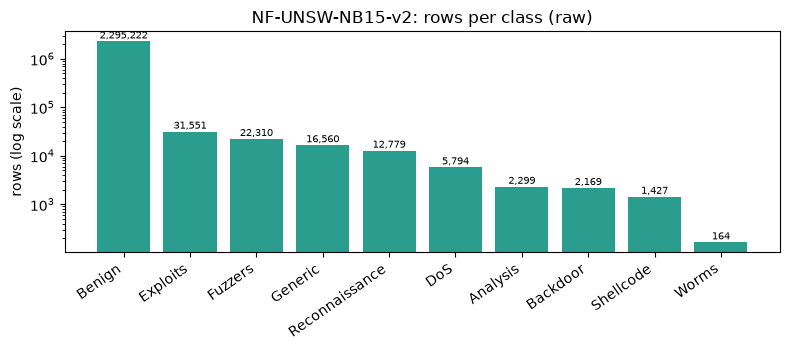

In [3]:
vc = df["Attack"].value_counts()
display(pd.DataFrame({"rows": vc, "share %": (100 * vc / len(df)).round(3)}))
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.bar(vc.index, vc.values, color="#2A9D8F"); ax.set_yscale("log"); ax.set_ylabel("rows (log scale)")
ax.set_title("NF-UNSW-NB15-v2: rows per class (raw)"); plt.xticks(rotation=35, ha="right")
for i, v in enumerate(vc.values): ax.text(i, v * 1.15, f"{v:,}", ha="center", fontsize=7)
fig.tight_layout(); fig.savefig(FIG / "eda_class_counts.png", dpi=150); plt.show()

## 3. Missing and infinite values

In [4]:
num = df.select_dtypes("number")
print("NaN cells :", int(df.isna().sum().sum()))
print("inf cells :", int(np.isinf(num).sum().sum()))
print("negative values in any column:", bool((num < 0).any().any()))
print("constant columns:", [c for c in features_all if df[c].nunique() <= 1])

NaN cells : 0


inf cells : 0
negative values in any column: False


constant columns: []


## 4. Identifier columns

IP addresses and ports identify *hosts*, not attack behaviour: a model can memorise "this IP is the
attacker" and score well for the wrong reason. `DNS_QUERY_ID` is a random 16-bit transaction number:
it carries no behaviour but makes otherwise-identical flows look different. All five are dropped.

In [5]:
ids = ["IPV4_SRC_ADDR", "IPV4_DST_ADDR", "L4_SRC_PORT", "L4_DST_PORT", "DNS_QUERY_ID"]
display(pd.DataFrame({"unique values": df[ids].nunique(), "example": df[ids].iloc[0]}))
src_attack = df.groupby("IPV4_SRC_ADDR")["Label"].mean()
print(f"source IPs: {len(src_attack)}; IPs whose flows are ALL attacks: {(src_attack == 1).sum()}, "
      f"ALL benign: {(src_attack == 0).sum()}  -> IP alone nearly reveals the label")

,unique values,example
IPV4_SRC_ADDR,40,59.166.0.5
IPV4_DST_ADDR,40,149.171.126.8
L4_SRC_PORT,64601,1305
L4_DST_PORT,64625,21
DNS_QUERY_ID,64243,0


source IPs: 40; IPs whose flows are ALL attacks: 0, ALL benign: 36  -> IP alone nearly reveals the label


## 5. Duplicates - the biggest finding

With identifiers removed, most rows are exact copies of another row. If duplicates are not removed
**before** the split, the same flow lands in train and test, and accuracy becomes fake (Gap 4 in our paper).

,duplicate rows,share %
raw (all columns),0,0.0
IPs + ports dropped,2149069,89.9
IPs + ports + DNS_QUERY_ID dropped,2282032,95.5


feature vectors that appear with MORE THAN ONE label: 1,563 (covering 5,781 rows) -> resolved by majority label


,raw,unique,kept %
Attack,,,
Analysis,2299,762,33.1
Backdoor,2169,679,31.3
Benign,2295222,68992,3.0
DoS,5794,3768,65.0
Exploits,31551,22797,72.3
Fuzzers,22310,7399,33.2
Generic,16560,2363,14.3
Reconnaissance,12779,1120,8.8
Shellcode,1427,300,21.0


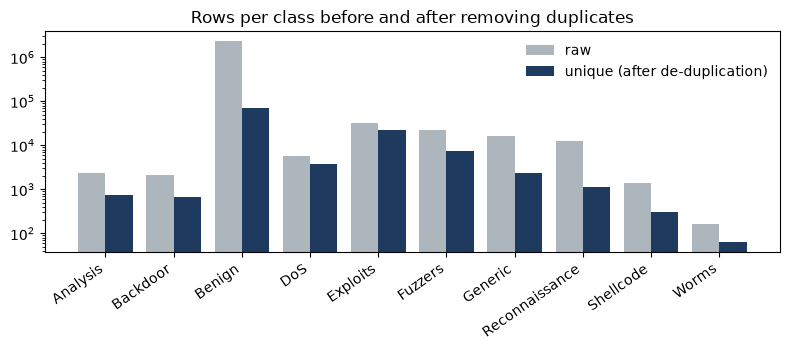

In [6]:
label = "Attack"
f4 = [c for c in features_all if c not in ids[:4]]          # IPs/ports dropped, DNS_QUERY_ID kept
f5 = [c for c in features_all if c not in ids]              # all five identifiers dropped
rows = {
    "raw (all columns)": int(df.duplicated().sum()),
    "IPs + ports dropped": int(df.duplicated(subset=f4 + [label]).sum()),
    "IPs + ports + DNS_QUERY_ID dropped": int(df.duplicated(subset=f5 + [label]).sum()),
}
display(pd.DataFrame({"duplicate rows": rows, "share %": {k: round(100 * v / len(df), 1) for k, v in rows.items()}}))
uniq = df.drop_duplicates(subset=f5 + [label])
conf = uniq.duplicated(subset=f5, keep=False)
print(f"feature vectors that appear with MORE THAN ONE label: {uniq[conf].drop_duplicates(subset=f5).shape[0]:,} "
      f"(covering {int(conf.sum()):,} rows) -> resolved by majority label")
cmp_ = pd.DataFrame({"raw": df[label].value_counts(), "unique": uniq[label].value_counts()})
cmp_["kept %"] = (100 * cmp_["unique"] / cmp_["raw"]).round(1)
display(cmp_)
fig, ax = plt.subplots(figsize=(8, 3.6)); x = np.arange(len(cmp_))
ax.bar(x - 0.2, cmp_["raw"], 0.4, label="raw", color="#ADB5BD"); ax.bar(x + 0.2, cmp_["unique"], 0.4, label="unique (after de-duplication)", color="#1F3A5F")
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(cmp_.index, rotation=35, ha="right"); ax.legend(frameon=False)
ax.set_title("Rows per class before and after removing duplicates"); fig.tight_layout()
fig.savefig(FIG / "eda_duplicates.png", dpi=150); plt.show()

## 6. Heavy-tailed features
Byte and packet counters are mostly small with a few huge values. `log1p` squeezes them into a range a neural network can learn from.

,skewness
SRC_TO_DST_SECOND_BYTES,1417.0
DST_TO_SRC_SECOND_BYTES,962.1
DNS_TTL_ANSWER,369.8
DNS_QUERY_TYPE,274.7
RETRANSMITTED_IN_BYTES,259.8
IN_BYTES,259.0
RETRANSMITTED_IN_PKTS,233.6
NUM_PKTS_256_TO_512_BYTES,217.5
IN_PKTS,75.9
DURATION_IN,31.1


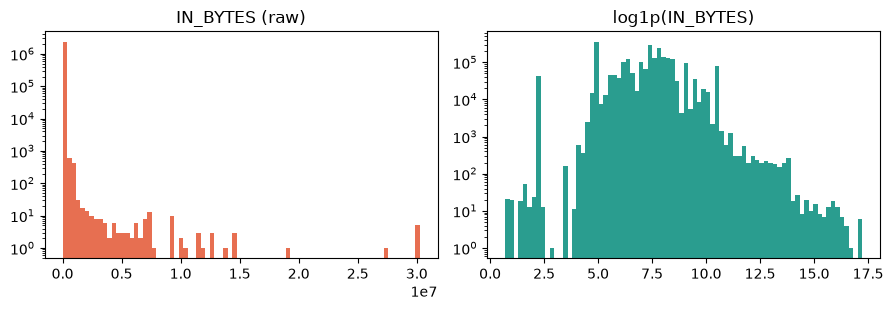

In [7]:
sk = df[f5].skew().sort_values(ascending=False)
display(sk.head(10).round(1).rename("skewness").to_frame())
fig, axs = plt.subplots(1, 2, figsize=(9, 3.2))
axs[0].hist(df["IN_BYTES"], bins=80, color="#E76F51"); axs[0].set_yscale("log"); axs[0].set_title("IN_BYTES (raw)")
axs[1].hist(np.log1p(df["IN_BYTES"]), bins=80, color="#2A9D8F"); axs[1].set_yscale("log"); axs[1].set_title("log1p(IN_BYTES)")
fig.tight_layout(); fig.savefig(FIG / "eda_log1p.png", dpi=150); plt.show()

## 7. The processed dataset (output of `scripts/prepare_data.py`)

In [8]:
m = json.load(open(REPO_ROOT / "data" / "processed" / "nf_unsw_manifest.json"))
print("fingerprint:", m["fingerprint"], "| features:", len(m["features"]), "| cleaning:", json.dumps({k: v for k, v in m["cleaning"].items() if not isinstance(v, (dict, list))}))
display(pd.DataFrame(m["class_counts"]).loc[m["classes"]].fillna(0).astype(int))
print("rows:", m["rows"])

fingerprint: 7d2ba3260f5740ab | features: 38 | cleaning: {"rows_raw": 2390275, "rows_dropped_inf_nan": 0, "rows_exact_duplicates": 2282035, "vectors_with_conflicting_labels": 1563, "rows_after_dedup": 104022}


,train,val,test
Benign,20000,5519,13797
Analysis,524,58,146
Backdoor,200,22,55
DoS,2234,249,621
Exploits,15734,1748,4371
Fuzzers,4856,540,1349
Generic,1241,138,345
Reconnaissance,246,27,68
Shellcode,154,17,43
Worms,36,4,10


rows: {'train_before_cap': 74895, 'train': 45225, 'val': 8322, 'test': 20805}


## 8. Non-IID client partitions (output of `scripts/make_partitions.py`)

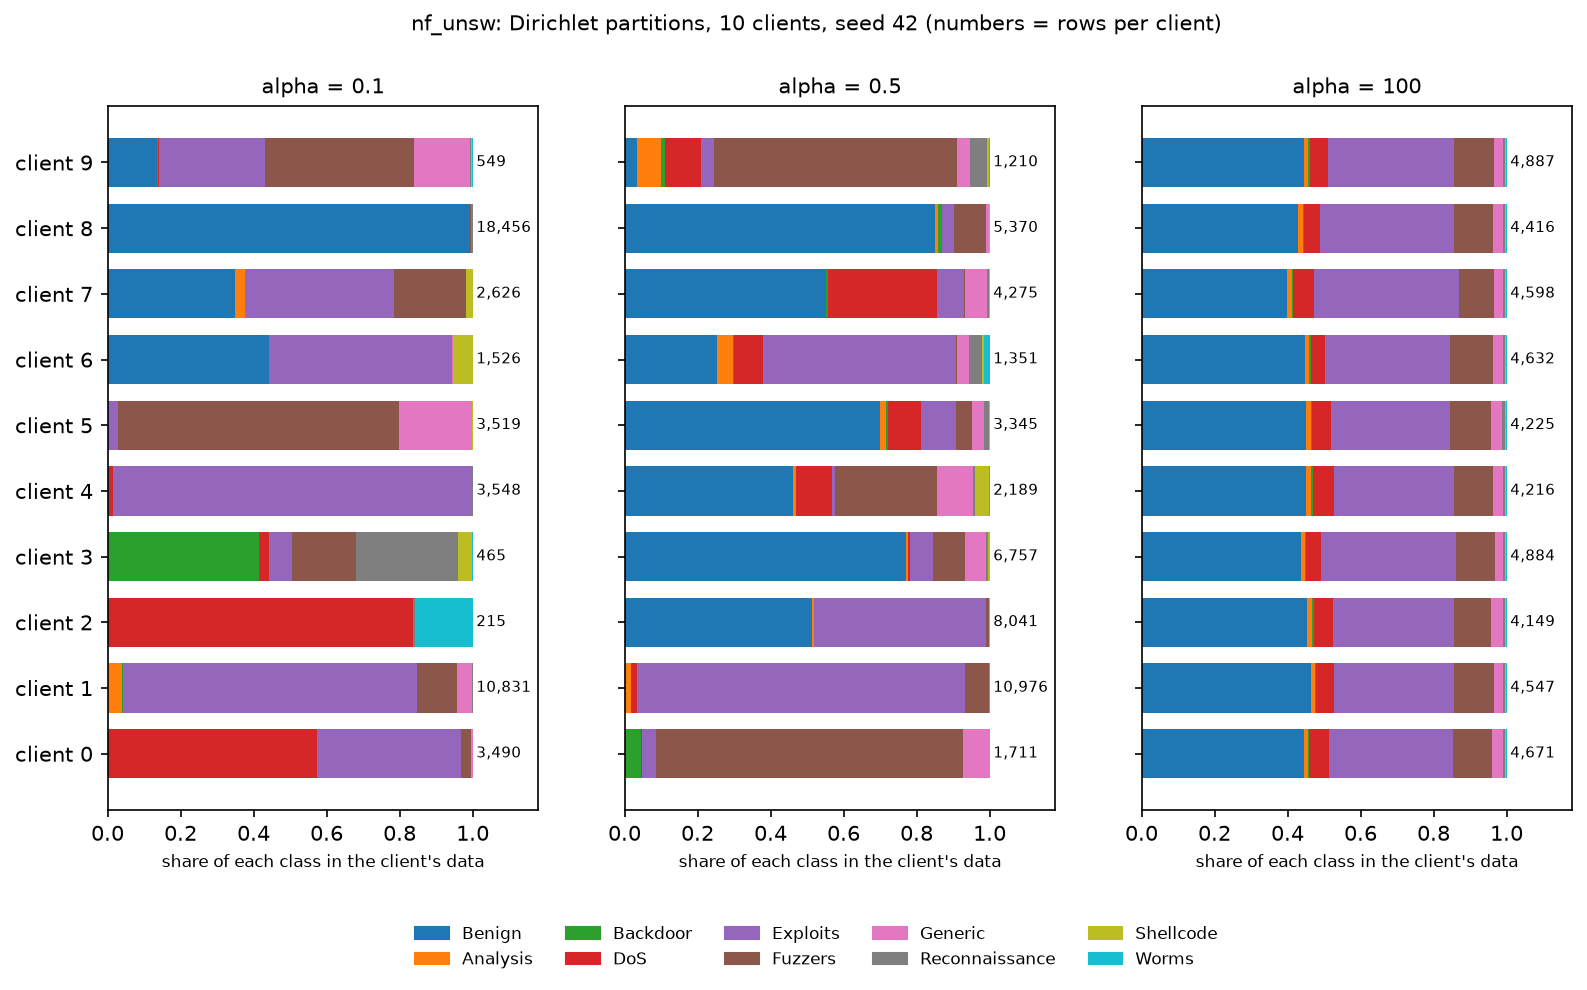

In [9]:
from IPython.display import Image
Image(str(FIG / "partitions_nf_unsw_k10_seed42.png"))

## Answers for the report

| Question | Answer |
|---|---|
| Size | 2,390,275 flows, 43 NetFlow features + `Label` + `Attack` |
| Class balance | 96% benign; rarest class Worms (164 raw rows, 50 unique) |
| Missing / infinite values | none |
| Identifier columns | `IPV4_SRC_ADDR`, `IPV4_DST_ADDR`, `L4_SRC_PORT`, `L4_DST_PORT`, `DNS_QUERY_ID` - dropped |
| Duplicates | ~95% of rows are duplicates once identifiers are removed; de-duplicated **before** the split |
| Conflicting labels | ~1.5k feature vectors carry more than one label; majority label kept |
| Heavy tails | byte/packet counters extremely skewed; `log1p` applied |
| Final data | ~104k unique rows, 38 features; train capped at 20k rows per class; val/test keep the natural mix |

**Consequence for comparisons:** papers that do not de-duplicate (for example the 91-93% in ref [1])
are not directly comparable with our numbers; the report must say so.